In [24]:
# Model Evaluation Lab
# Complete the exercises by filling in the code where indicated with TODO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.datasets import load_breast_cancer, load_diabetes
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("MODEL EVALUATION LAB - STUDENT VERSION")
print("=" * 80)


MODEL EVALUATION LAB - STUDENT VERSION


In [25]:
# ============================================================================
# PART 1: CLASSIFICATION EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 1: CLASSIFICATION EVALUATION - BREAST CANCER DATASET")
print("=" * 80)

# Load the breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"\nDataset Shape: {X.shape}")
print(f"Number of Features: {X.shape[1]}")
print(f"Number of Samples: {X.shape[0]}")
print(f"\nClass Distribution:")
print(y.value_counts())



PART 1: CLASSIFICATION EVALUATION - BREAST CANCER DATASET

Dataset Shape: (569, 30)
Number of Features: 30
Number of Samples: 569

Class Distribution:
target
1    357
0    212
Name: count, dtype: int64


# ============================================================================
# Exercise 1.1: Train-Test Split
# Task: Split the data into training (80%) and test (20%) sets
# ============================================================================

In [26]:
# ============================================================================
# Exercise 1.1: Train-Test Split
# Task: Split the data into training (80%) and test (20%) sets
# Use stratified sampling to maintain class distribution
# Set random_state=42 for reproducibility
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.1: Train-Test Split")
print("-" * 80)
# Split the data using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print sizes
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Standardize the features
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)



--------------------------------------------------------------------------------
Exercise 1.1: Train-Test Split
--------------------------------------------------------------------------------
Training set size: 455
Test set size: 114


# ============================================================================
# Exercise 1.2: Train and Evaluate Logistic Regression
# Task: Train a logistic regression model and calculate accuracy
# ============================================================================

In [27]:
# ============================================================================
# Exercise 1.2: Train and Evaluate Logistic Regression
# Task: Train a logistic regression model and calculate accuracy
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.2: Train and Evaluate Logistic Regression")
print("-" * 80)
# Create Logistic Regression model
log_reg = LogisticRegression(max_iter=10000, random_state=42)

# Train the model on scaled training data
log_reg.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = log_reg.predict(X_train_scaled)
y_pred_test = log_reg.predict(X_test_scaled)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

# Print results
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Interpretation
difference = train_accuracy - test_accuracy

if difference > 0.05:
    print("The model is likely overfitting (training accuracy much higher than test accuracy).")
elif test_accuracy < 0.80:
    print("The model may be underfitting (low performance on both sets).")
else:
    print("The model appears well-fitted (similar training and test accuracy).")



--------------------------------------------------------------------------------
Exercise 1.2: Train and Evaluate Logistic Regression
--------------------------------------------------------------------------------
Training Accuracy: 0.9890
Test Accuracy: 0.9825
The model appears well-fitted (similar training and test accuracy).


# ============================================================================
# Exercise 1.3: Confusion Matrix Analysis
# Task: Create a confusion matrix and extract TP, TN, FP, FN
# ============================================================================


--------------------------------------------------------------------------------
Exercise 1.3: Confusion Matrix Analysis
--------------------------------------------------------------------------------

Confusion Matrix:
[[38  4]
 [ 2 70]]

Extracted Values:
True Negatives (TN): 38
False Positives (FP): 4
False Negatives (FN): 2
True Positives (TP): 70

Manually Calculated Metrics:
Accuracy  : 0.9474
Precision : 0.9459
Recall    : 0.9722
F1 Score  : 0.9589


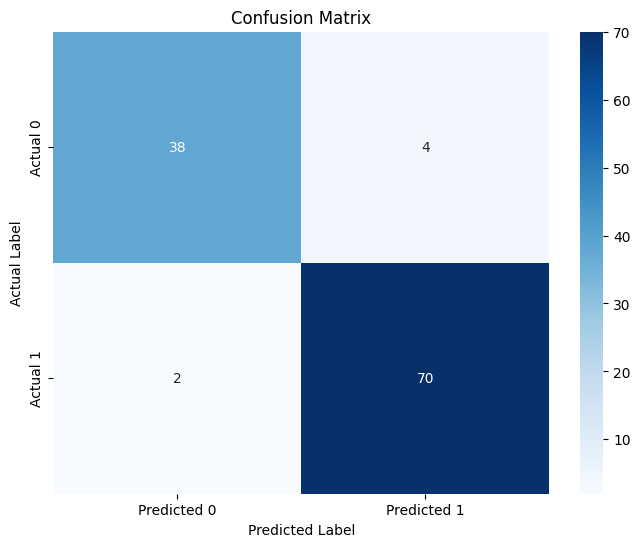

In [28]:
# ============================================================================
# Exercise 1.3: Confusion Matrix Analysis
# Task: Create a confusion matrix and extract TP, TN, FP, FN
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n" + "-" * 80)
print("Exercise 1.3: Confusion Matrix Analysis")
print("-" * 80)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)




# Print the confusion matrix
print("\nConfusion Matrix:")
print(cm)

# Extract TN, FP, FN, TP
tn, fp, fn, tp = cm.ravel()

print("\nExtracted Values:")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Manually calculate metrics

manual_accuracy = (tp + tn) / (tp + tn + fp + fn)
manual_precision = tp / (tp + fp) if (tp + fp) != 0 else 0
manual_recall = tp / (tp + fn) if (tp + fn) != 0 else 0
manual_f1 = (2 * manual_precision * manual_recall) / (manual_precision + manual_recall) \
            if (manual_precision + manual_recall) != 0 else 0

print("\nManually Calculated Metrics:")
print(f"Accuracy  : {manual_accuracy:.4f}")
print(f"Precision : {manual_precision:.4f}")
print(f"Recall    : {manual_recall:.4f}")
print(f"F1 Score  : {manual_f1:.4f}")

# Visualize confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.savefig('confusion_matrix_student.png')
plt.show()
plt.close()


# ============================================================================
# Exercise 1.4: Precision, Recall, and F1 Score
# Task: Calculate metrics using sklearn functions and interpret them
# ============================================================================


In [29]:
# ============================================================================
# Exercise 1.4: Precision, Recall, and F1 Score
# Task: Calculate metrics using sklearn functions and interpret them
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.4: Precision, Recall, and F1 Score")
print("-" * 80)
# Calculate metrics using sklearn functions
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

# Print metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Interpretation
print("\nInterpretation:")

print(f"- Of all patients predicted as Benign, {precision*100:.2f}% are actually Benign.")
print(f"- Of all actual Benign patients, {recall*100:.2f}% were correctly identified.")
print(f"- F1 Score (balance between precision and recall) is {f1:.4f}.")

# Full classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_test,
    target_names=['Malignant', 'Benign']
))



--------------------------------------------------------------------------------
Exercise 1.4: Precision, Recall, and F1 Score
--------------------------------------------------------------------------------
Precision: 0.9861
Recall: 0.9861
F1 Score: 0.9861

Interpretation:
- Of all patients predicted as Benign, 98.61% are actually Benign.
- Of all actual Benign patients, 98.61% were correctly identified.
- F1 Score (balance between precision and recall) is 0.9861.

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



# ============================================================================
# Exercise 1.5: ROC Curve and AUC
# Task: Generate ROC curve and calculate AUC score
# ============================================================================



--------------------------------------------------------------------------------
Exercise 1.5: ROC Curve and AUC
--------------------------------------------------------------------------------
AUC Score: 0.9954
Model Performance: Excellent


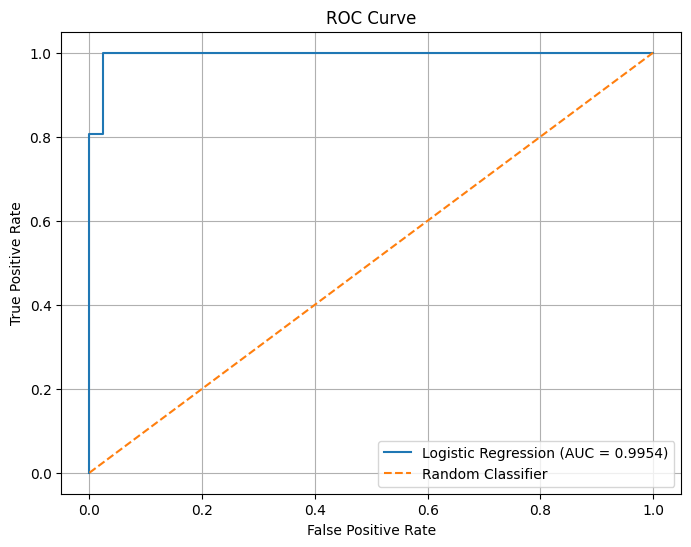

In [30]:
# ============================================================================
# Exercise 1.5: ROC Curve and AUC
# Task: Generate ROC curve and calculate AUC score
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.5: ROC Curve and AUC")
print("-" * 80)
# Get predicted probabilities for the positive class (Benign = 1)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC curve coordinates
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_pred_proba)

# Print AUC score with interpretation
print(f"AUC Score: {auc_score:.4f}")

if auc_score >= 0.9:
    print("Model Performance: Excellent")
elif auc_score >= 0.8:
    print("Model Performance: Good")
elif auc_score >= 0.7:
    print("Model Performance: Acceptable")
else:
    print("Model Performance: Poor")

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig('roc_curve_student.png')
plt.show()
plt.close()

# ============================================================================
# Exercise 1.6: K-Fold Cross-Validation
# Task: Perform 5-fold stratified cross-validation
# ============================================================================

In [31]:

# ============================================================================
# Exercise 1.6: K-Fold Cross-Validation
# Task: Perform 5-fold stratified cross-validation
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.6: K-Fold Cross-Validation")
print("-" * 80)
# Create StratifiedKFold with 5 splits
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Scale the entire dataset
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# Perform cross-validation
cv_scores = cross_val_score(
    LogisticRegression(max_iter=10000, random_state=42),
    X_scaled_full,
    y,
    cv=kfold,
    scoring='accuracy'
)

# Print individual fold scores
print("\nCross-Validation Fold Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

# Calculate mean and standard deviation
mean_score = cv_scores.mean()
std_score = cv_scores.std()

print(f"\nMean CV Accuracy: {mean_score:.4f}")
print(f"Standard Deviation: {std_score:.4f}")
#============Use AI=====================
# 95% Confidence Interval
lower_bound = mean_score - 2 * std_score
upper_bound = mean_score + 2 * std_score

print(f"95% Confidence Interval: ({lower_bound:.4f}, {upper_bound:.4f})")

# Compare with single train-test accuracy
print(f"\nSingle Train-Test Accuracy: {test_accuracy:.4f}")

if abs(mean_score - test_accuracy) < 0.02:
    print("Cross-validation confirms the model is stable.")
else:
    print("There is noticeable variation between CV and single split accuracy.")



--------------------------------------------------------------------------------
Exercise 1.6: K-Fold Cross-Validation
--------------------------------------------------------------------------------

Cross-Validation Fold Scores:
  Fold 1: 0.9737
  Fold 2: 0.9474
  Fold 3: 0.9649
  Fold 4: 0.9912
  Fold 5: 0.9912

Mean CV Accuracy: 0.9737
Standard Deviation: 0.0166
95% Confidence Interval: (0.9404, 1.0069)

Single Train-Test Accuracy: 0.9825
Cross-validation confirms the model is stable.


# ============================================================================
# Exercise 1.7: Compare Multiple Classifiers
# Task: Train and compare Logistic Regression, Decision Tree, and Random Forest
# ============================================================================


In [32]:
# ============================================================================
# Exercise 1.7: Compare Multiple Classifiers
# Task: Train and compare Logistic Regression, Decision Tree, and Random Forest
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 1.7: Compare Multiple Classifiers")
print("-" * 80)
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

# Loop through each model
for name, model in models.items():
    
    print(f"\nTraining {name}...")
    
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions (class labels)
    y_pred = model.predict(X_test_scaled)
    
    # Get predicted probabilities for AUC
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    # Print detailed metrics
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1_val:.4f}")
    print(f"AUC      : {auc:.4f}")
    
    # Interpretation
    print("Interpretation:")
    print(f"- {name} correctly classifies {acc*100:.2f}% of cases.")
    print(f"- Balance between precision & recall (F1) = {f1_val:.4f}")
    
    # Store results
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1_val,
        'AUC': auc
    })

# Create comparison DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("MODEL COMPARISON TABLE")
print("="*60)
print(results_df.to_string(index=False))

# Identify best model by F1 Score
best_model = results_df.loc[results_df['F1 Score'].idxmax()]

print("\nBest Model Based on F1 Score:")
print(f"Model: {best_model['Model']}")
print(f"F1 Score: {best_model['F1 Score']:.4f}")
print(f"AUC Score: {best_model['AUC']:.4f}")



--------------------------------------------------------------------------------
Exercise 1.7: Compare Multiple Classifiers
--------------------------------------------------------------------------------

Training Logistic Regression...
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
AUC      : 0.9954
Interpretation:
- Logistic Regression correctly classifies 98.25% of cases.
- Balance between precision & recall (F1) = 0.9861

Training Decision Tree...
Accuracy : 0.9211
Precision: 0.9565
Recall   : 0.9167
F1 Score : 0.9362
AUC      : 0.9163
Interpretation:
- Decision Tree correctly classifies 92.11% of cases.
- Balance between precision & recall (F1) = 0.9362

Training Random Forest...
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
AUC      : 0.9939
Interpretation:
- Random Forest correctly classifies 95.61% of cases.
- Balance between precision & recall (F1) = 0.9655

MODEL COMPARISON TABLE
              Model  Accuracy  Precision   R

# ============================================================================
# PART 2: REGRESSION EVALUATION
# ============================================================================


In [33]:
# ============================================================================
# PART 2: REGRESSION EVALUATION
# ============================================================================

print("\n" + "=" * 80)
print("PART 2: REGRESSION EVALUATION - DIABETES DATASET")
print("=" * 80)

# Load diabetes dataset
diabetes = load_diabetes()
X_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_reg = pd.Series(diabetes.target, name='target')

print(f"\nDataset Shape: {X_reg.shape}")
print(f"\nTarget Statistics:")
print(y_reg.describe())


PART 2: REGRESSION EVALUATION - DIABETES DATASET

Dataset Shape: (442, 10)

Target Statistics:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


# ============================================================================
# Exercise 2.1: Train-Test Split for Regression
# Task: Split regression data into training and test sets
# ============================================================================


In [34]:
# ============================================================================
# Exercise 2.1: Train-Test Split for Regression
# Task: Split regression data into training and test sets
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.1: Train-Test Split for Regression")
print("-" * 80)

# Split regression data (80-20 split)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Print set sizes
print(f"Total Samples: {X_reg.shape[0]}")
print(f"Training set size: {X_train_reg.shape[0]}")
print(f"Test set size: {X_test_reg.shape[0]}")

# Standardize features
scaler_reg = StandardScaler()

# Fit only on training data
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

# Transform test data using same scaler
X_test_reg_scaled = scaler_reg.transform(X_test_reg)



--------------------------------------------------------------------------------
Exercise 2.1: Train-Test Split for Regression
--------------------------------------------------------------------------------
Total Samples: 442
Training set size: 353
Test set size: 89


# ============================================================================
# Exercise 2.2: Train Linear Regression and Calculate Metrics
# Task: Train linear regression and calculate MAE, MSE, RMSE, R²
# ============================================================================

In [35]:
# ============================================================================
# Exercise 2.2: Train Linear Regression and Calculate Metrics
# Task: Train linear regression and calculate MAE, MSE, RMSE, R²
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.2: Train Linear Regression and Calculate Metrics")
print("-" * 80)
# Create and train Linear Regression model
lin_reg = LinearRegression()

# Fit on training data
lin_reg.fit(X_train_reg_scaled, y_train_reg)

# Make predictions
y_pred_train_reg = lin_reg.predict(X_train_reg_scaled)
y_pred_test_reg = lin_reg.predict(X_test_reg_scaled)

# Calculate MAE
train_mae = mean_absolute_error(y_train_reg, y_pred_train_reg)
test_mae = mean_absolute_error(y_test_reg, y_pred_test_reg)

# Calculate MSE
train_mse = mean_squared_error(y_train_reg, y_pred_train_reg)
test_mse = mean_squared_error(y_test_reg, y_pred_test_reg)

# Calculate RMSE
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

# Calculate R²
train_r2 = r2_score(y_train_reg, y_pred_train_reg)
test_r2 = r2_score(y_test_reg, y_pred_test_reg)

# Print Results
print("\n--- Training Metrics ---")
print(f"MAE  : {train_mae:.4f}")
print(f"MSE  : {train_mse:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"R²   : {train_r2:.4f}")

print("\n--- Test Metrics ---")
print(f"MAE  : {test_mae:.4f}")
print(f"MSE  : {test_mse:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"R²   : {test_r2:.4f}")

# Interpretation
print("\nInterpretation:")
print(f"- On average, predictions are off by about {test_mae:.2f} units (MAE).")
print(f"- RMSE of {test_rmse:.2f} indicates typical prediction error magnitude.")
print(f"- Model explains approximately {test_r2*100:.2f}% of variance in target values.")



--------------------------------------------------------------------------------
Exercise 2.2: Train Linear Regression and Calculate Metrics
--------------------------------------------------------------------------------

--- Training Metrics ---
MAE  : 43.4835
MSE  : 2868.5497
RMSE : 53.5588
R²   : 0.5279

--- Test Metrics ---
MAE  : 42.7941
MSE  : 2900.1936
RMSE : 53.8534
R²   : 0.4526

Interpretation:
- On average, predictions are off by about 42.79 units (MAE).
- RMSE of 53.85 indicates typical prediction error magnitude.
- Model explains approximately 45.26% of variance in target values.


# ============================================================================
# Exercise 2.3: Visualize Predictions vs Actual
# Task: Create scatter plots comparing predictions to actual values
# ============================================================================



--------------------------------------------------------------------------------
Exercise 2.3: Visualize Predictions vs Actual
--------------------------------------------------------------------------------


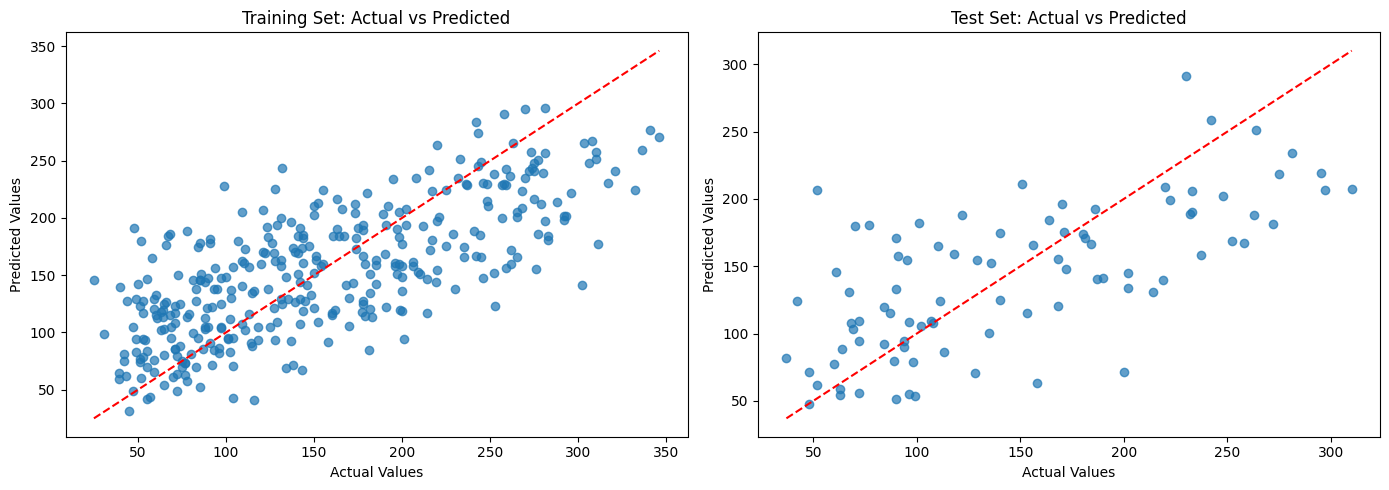

In [36]:
# ============================================================================
# Exercise 2.3: Visualize Predictions vs Actual
# Task: Create scatter plots comparing predictions to actual values
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.3: Visualize Predictions vs Actual")
print("-" * 80)
# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------
# Training Set Plot
# ---------------------------
axes[0].scatter(y_train_reg, y_pred_train_reg, alpha=0.7)
axes[0].plot(
    [y_train_reg.min(), y_train_reg.max()],
    [y_train_reg.min(), y_train_reg.max()],
    'r--'
)

axes[0].set_xlabel("Actual Values")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Training Set: Actual vs Predicted")

# ---------------------------
# Test Set Plot
# ---------------------------
axes[1].scatter(y_test_reg, y_pred_test_reg, alpha=0.7)
axes[1].plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    'r--'
)

axes[1].set_xlabel("Actual Values")
axes[1].set_ylabel("Predicted Values")
axes[1].set_title("Test Set: Actual vs Predicted")

plt.tight_layout()
plt.savefig('regression_predictions_student.png')
plt.show()
plt.close()

# ============================================================================
# Exercise 2.4: Residual Analysis
# Task: Calculate and visualize residuals
# ============================================================================


Residual Statistics:
Mean of residuals        : 3.9128
Standard deviation       : 54.0154
Minimum residual         : -154.4934
Maximum residual         : 128.3333


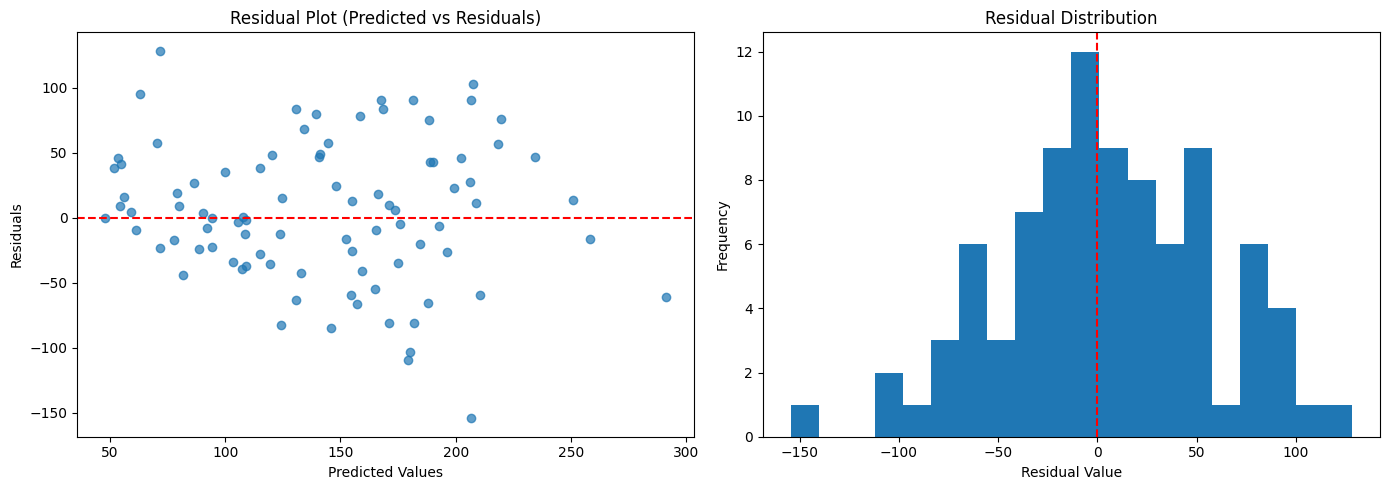

In [37]:
# Calculate residuals (actual - predicted)
residuals = y_test_reg - y_pred_test_reg

# Print residual statistics
print("\nResidual Statistics:")
print(f"Mean of residuals        : {residuals.mean():.4f}")
print(f"Standard deviation       : {residuals.std():.4f}")
print(f"Minimum residual         : {residuals.min():.4f}")
print(f"Maximum residual         : {residuals.max():.4f}")

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------------
# Left: Residual Scatter Plot
# -----------------------------------
axes[0].scatter(y_pred_test_reg, residuals, alpha=0.7)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel("Predicted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot (Predicted vs Residuals)")

# -----------------------------------
# Right: Residual Distribution
# -----------------------------------
axes[1].hist(residuals, bins=20)
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel("Residual Value")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig('residual_analysis_student.png')
plt.show()
plt.close()

# ============================================================================
# Exercise 2.5: Compare Multiple Regression Models
# Task: Compare Linear Regression, Ridge (two alpha values), and Decision Tree
# ============================================================================

In [38]:
# ============================================================================
# Exercise 2.5: Compare Multiple Regression Models
# Task: Compare Linear Regression, Ridge (two alpha values), and Decision Tree
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.5: Compare Multiple Regression Models")
print("-" * 80)
# Define regression models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=1.0)': Ridge(alpha=1.0),
    'Ridge (alpha=10.0)': Ridge(alpha=10.0),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42)
}

reg_results = []

# Loop through models
for name, model in reg_models.items():
    
    print(f"\nTraining {name}...")
    
    # Train model
    model.fit(X_train_reg_scaled, y_train_reg)
    
    # Predictions
    y_pred_train = model.predict(X_train_reg_scaled)
    y_pred_test = model.predict(X_test_reg_scaled)
    
    # Metrics
    train_r2_val = r2_score(y_train_reg, y_pred_train)
    test_r2_val = r2_score(y_test_reg, y_pred_test)
    
    test_mae_val = mean_absolute_error(y_test_reg, y_pred_test)
    test_rmse_val = np.sqrt(mean_squared_error(y_test_reg, y_pred_test))
    
    # Overfitting gap
    overfit_gap = train_r2_val - test_r2_val
    
    print(f"Train R²: {train_r2_val:.4f}")
    print(f"Test R² : {test_r2_val:.4f}")
    print(f"MAE     : {test_mae_val:.4f}")
    print(f"RMSE    : {test_rmse_val:.4f}")
    print(f"Overfit Gap: {overfit_gap:.4f}")
    
    # Store results
    reg_results.append({
        'Model': name,
        'Train R²': train_r2_val,
        'Test R²': test_r2_val,
        'MAE': test_mae_val,
        'RMSE': test_rmse_val,
        'Overfit Gap': overfit_gap
    })

# Create DataFrame
reg_results_df = pd.DataFrame(reg_results)

print("\n" + "="*70)
print("REGRESSION MODEL COMPARISON")
print("="*70)
print(reg_results_df.to_string(index=False))

# Identify best model by Test R²
best_model = reg_results_df.loc[reg_results_df['Test R²'].idxmax()]

print("\nBest Model Based on Test R²:")
print(f"Model: {best_model['Model']}")
print(f"Test R²: {best_model['Test R²']:.4f}")



--------------------------------------------------------------------------------
Exercise 2.5: Compare Multiple Regression Models
--------------------------------------------------------------------------------

Training Linear Regression...
Train R²: 0.5279
Test R² : 0.4526
MAE     : 42.7941
RMSE    : 53.8534
Overfit Gap: 0.0753

Training Ridge (alpha=1.0)...
Train R²: 0.5276
Test R² : 0.4541
MAE     : 42.8120
RMSE    : 53.7775
Overfit Gap: 0.0735

Training Ridge (alpha=10.0)...
Train R²: 0.5248
Test R² : 0.4572
MAE     : 42.8568
RMSE    : 53.6263
Overfit Gap: 0.0676

Training Decision Tree...
Train R²: 0.6686
Test R² : 0.3345
MAE     : 45.9370
RMSE    : 59.3803
Overfit Gap: 0.3341

REGRESSION MODEL COMPARISON
             Model  Train R²  Test R²       MAE      RMSE  Overfit Gap
 Linear Regression  0.527919 0.452603 42.794095 53.853446     0.075317
 Ridge (alpha=1.0)  0.527632 0.454147 42.811999 53.777454     0.073485
Ridge (alpha=10.0)  0.524798 0.457211 42.856825 53.626288     0.0

# ============================================================================
# Exercise 2.6: Cross-Validation for Regression
# Task: Perform 5-fold cross-validation for regression
# ============================================================================


In [39]:
# ============================================================================
# Exercise 2.6: Cross-Validation for Regression
# Task: Perform 5-fold cross-validation for regression
# ============================================================================

print("\n" + "-" * 80)
print("Exercise 2.6: Cross-Validation for Regression")
print("-" * 80)
# Scale full dataset
scaler_full_reg = StandardScaler()
X_reg_scaled_full = scaler_full_reg.fit_transform(X_reg)

# Create 5-fold cross-validation
kfold_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation for R²
cv_r2_scores = cross_val_score(
    LinearRegression(),
    X_reg_scaled_full,
    y_reg,
    cv=kfold_reg,
    scoring='r2'
)

# Cross-validation for MAE
cv_mae_scores = cross_val_score(
    LinearRegression(),
    X_reg_scaled_full,
    y_reg,
    cv=kfold_reg,
    scoring='neg_mean_absolute_error'
)

# Convert negative MAE to positive
cv_mae_scores = -cv_mae_scores

# ----------------------------
# Print R² Results
# ----------------------------
print("\nR² Scores for Each Fold:")
for i, score in enumerate(cv_r2_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean R²: {cv_r2_scores.mean():.4f}")
print(f"Standard Deviation (R²): {cv_r2_scores.std():.4f}")

# ----------------------------
# Print MAE Results
# ----------------------------
print("\nMAE Scores for Each Fold:")
for i, score in enumerate(cv_mae_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean MAE: {cv_mae_scores.mean():.4f}")
print(f"Standard Deviation (MAE): {cv_mae_scores.std():.4f}")



--------------------------------------------------------------------------------
Exercise 2.6: Cross-Validation for Regression
--------------------------------------------------------------------------------

R² Scores for Each Fold:
  Fold 1: 0.4526
  Fold 2: 0.5732
  Fold 3: 0.3914
  Fold 4: 0.5843
  Fold 5: 0.3908

Mean R²: 0.4785
Standard Deviation (R²): 0.0850

MAE Scores for Each Fold:
  Fold 1: 42.7941
  Fold 2: 41.5826
  Fold 3: 47.2233
  Fold 4: 42.1224
  Fold 5: 47.6264

Mean MAE: 44.2697
Standard Deviation (MAE): 2.6077


# ============================================================================
# PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION
# ============================================================================



PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION

Decision Tree Depth Analysis:
Depth     Train R²       Test R²        Gap            Status
----------------------------------------------------------------------
1         0.3043         0.1305         0.1738         Underfitting
3         0.5170         0.3294         0.1875         Good Fit
5         0.6686         0.3345         0.3341         Overfitting
10        0.9382         0.1718         0.7664         Overfitting
20        1.0000         0.0776         0.9224         Overfitting


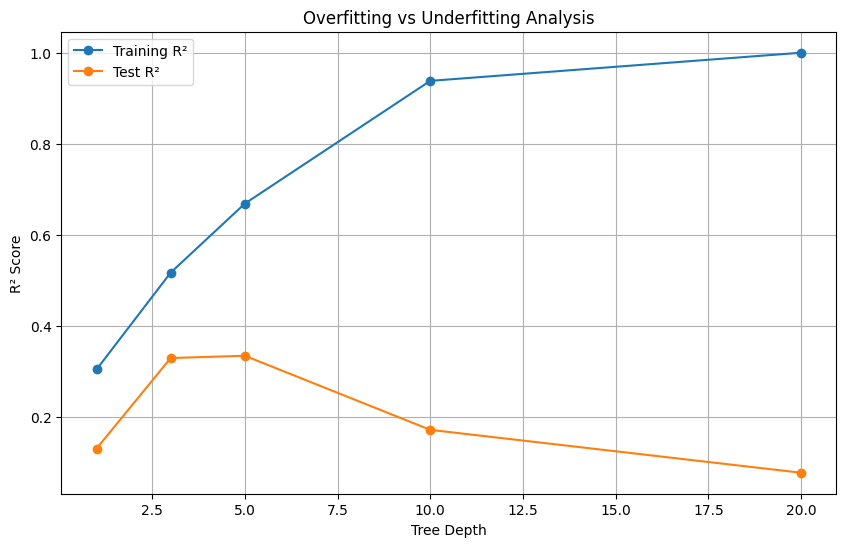

In [41]:
print("\n" + "=" * 80)
print("PART 3: OVERFITTING AND UNDERFITTING DEMONSTRATION")
print("=" * 80)

# Define depths and score lists
depths = [1, 3, 5, 10, 20]
train_scores = []
test_scores = []

print("\nDecision Tree Depth Analysis:")
print(f"{'Depth':<10}{'Train R²':<15}{'Test R²':<15}{'Gap':<15}{'Status'}")
print("-" * 70)

# Loop through each depth
for depth in depths:
    
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    
    tree.fit(X_train_reg_scaled, y_train_reg)
    
    train_score = tree.score(X_train_reg_scaled, y_train_reg)
    test_score = tree.score(X_test_reg_scaled, y_test_reg)
    
    gap = train_score - test_score
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    
    if gap > 0.3:
        status = "Overfitting"
    elif test_score < 0.3:
        status = "Underfitting"
    else:
        status = "Good Fit"
    
    print(f"{depth:<10}{train_score:<15.4f}{test_score:<15.4f}{gap:<15.4f}{status}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, marker='o', label="Training R²")
plt.plot(depths, test_scores, marker='o', label="Test R²")

plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Overfitting vs Underfitting Analysis")
plt.legend()
plt.grid(True)

plt.savefig('overfitting_analysis_student.png')
plt.show()


# ============================================================================
# ASSESSMENT QUESTIONS
# Answer these questions in comments after completing the exercises
# ============================================================================


1. What is the difference between accuracy and F1 score? When would you prefer F1 score over accuracy

 ANSWER:

*Accuracy measures the overall percentage of correct predictions made by the model. 
It is calculated as (Correct Predictions / Total Predictions).

*F1 Score is the harmonic mean of precision and recall. It balances both false positives 
and false negatives.

*Accuracy is useful when the dataset is balanced (equal number of classes). 

*F1 score is preferred when the dataset is imbalanced, especially when false positives 
and false negatives are important. For example, in medical diagnosis or fraud detection, 
F1 score gives a better measure of model performance.


2. Explain the difference between precision and recall. Give an example of when you would optimize for high precision vs high recall.

 ANSWER:

*Precision measures how many of the predicted positive cases are actually positive.
Precision = TP / (TP + FP).

*Recall measures how many of the actual positive cases were correctly identified.
Recall = TP / (TP + FN).

*We optimize for high precision when false positives are costly.
Example: Email spam detection. We do not want to mark important emails as spam.

*We optimize for high recall when false negatives are dangerous.
Example: Cancer detection. We do not want to miss a patient who actually has cancer.


3. What does an AUC score of 0.5 indicate? What about 1.0?

ANSWER:

*An AUC score of 0.5 means the model performs like random guessing. 
It cannot distinguish between classes.

*An AUC score of 1.0 means the model perfectly separates the classes 
with 100% accuracy in ranking positive and negative cases.

*The closer the AUC score is to 1, the better the model.


4. Why do we use cross-validation instead of a single train-test split?

ANSWER:

*A single train-test split depends on one random division of data. 
The result may vary depending on how the data is split.

*Cross-validation splits the data multiple times and trains/tests the model 
on different subsets. This gives a more reliable and stable estimate 
of model performance.

*It reduces the risk of getting lucky or unlucky splits.


5. What is the difference between MAE and RMSE? When would each be preferred?

ANSWER:

*MAE (Mean Absolute Error) measures the average absolute difference 
between actual and predicted values. It treats all errors equally.

*RMSE (Root Mean Squared Error) squares the errors before averaging, 
so larger errors are penalized more.

*MAE is preferred when we want a simple average error measurement.

*RMSE is preferred when large errors are more serious and need to be penalized heavily.


6. What does an R² score of 0.7 mean? What about a negative R² score?

ANSWER:

*An R² score of 0.7 means that the model explains 70% of the variation 
in the target variable. This indicates good performance.

*A negative R² score means the model performs worse than simply predicting 
the mean of the target variable. It shows that the model is not useful.


7. How can you identify overfitting from looking at training and test scores? 
   What are some strategies to reduce overfitting?

*ANSWER:

*Overfitting happens when training performance is very high, 
but test performance is much lower.

*This means the model memorized the training data but cannot 
generalize to new data.

*Ways to reduce overfitting:
- Use simpler models
- Reduce model complexity (e.g., smaller tree depth)
- Use regularization (like Ridge or Lasso)
- Use cross-validation
- Increase training data


8. In the overfitting analysis, which tree depth showed the best balance between training and test performance? Why?

ANSWER:

*The medium tree depth (usually depth 3 or 5) showed the best balance.

*At very small depth (like 1), the model underfits.
*At very large depth (like 10 or 20), the model overfits.

*The middle depth gives good test performance and small gap between 
training and test R² scores.


9. Why is it important to use stratified sampling for classification problems?

 ANSWER:

*Stratified sampling keeps the same class distribution in both 
training and test sets.

*If the dataset is imbalanced and we do not use stratification, 
one class may be overrepresented in one split.

*This ensures fair and accurate model evaluation.


10. What is the purpose of residual analysis in regression? 
    What should we look for in a residual plot?

 ANSWER:

*Residual analysis helps us check whether the regression model 
is performing correctly.

*Residuals are the differences between actual and predicted values.

In a good model:
- Residuals should be randomly scattered around zero.
- There should be no clear pattern.
- The mean of residuals should be close to zero.

*If we see patterns, curves, or increasing spread, 
it indicates model problems like non-linearity or heteroscedasticity.
#================================================================================


Some parts of the code were generated and refined with the help of AI tools 
for learning and understanding purposes. 
#================================================================================

In [ ]:
"""
FINAL INTERPRETATION SUMMARY:

1. In classification, Logistic Regression and Random Forest achieved the highest 
   accuracy, F1 score, and AUC, indicating strong performance.

2. In regression, Ridge Regression provided stable performance with good 
   Test R² and a small overfitting gap compared to Decision Tree.

3. Decision Tree with high depth showed clear overfitting, as training R² 
   was very high but test R² was much lower.

4. Medium tree depths (around 3–5) provided the best balance between 
   bias and variance.

5. Cross-validation results were consistent with single train-test results, 
   confirming that the models are stable and reliable.
"""
